# AIS lakehouse: Raw data -> Cleaned data in storage -> Query
Store the same ship-movement data (AIS) many different
ways on disk, then ask the same queries, and measure which storage layout answers
fastest without changing the query text.

The data lives in Parquet files on object storage (MinIO/S3), catalogued by Apache Iceberg, and queried with DuckDB + MobilityDuck. For example, when a query asks for "ships near this port last Tuesday", the engine can skip any file (or chunk of a file) whose stored min/max bounds don't overlap the question( pruning). How we arrange the rows into files decides how much can be skipped. Less data read = faster query.

One row = one trajectory segment (a piece of one ship's path). Every layout stores the identical columns (see §1); they differ only in "rows and how they are grouped into files".

### The layouts (how the rows are grouped)
| name | grouped by | note |
|---|---|---|
| **L0** | calendar day | the baseline: just split by day, no further spatial structure |
| **L1** | `hash(mmsi)` | scatter ships into N buckets, no spatial meaning |
| **L2** | 50 km **space tiles** (`spaceSplit`) | cut the map into 50 km squares; each file = one square, in each square there are smaller tiles |
| **L3** | 50 km **space tiles** (`MEST`) | same idea as L2, a different tiling method for smaller box in the square |
| **L4** | hour of day (`timeSplit`) | group by time |
| **LH** | **Hilbert curve** order | a space-filling curve that keeps nearby points nearby |

### Two storage "families" of those layouts
- daily: split by calendar day (so a file = one tile *on one day*). Many small files.
- sorted-compact (L1s, L2s, L3s, L4s, LHs): one file per tile for the
  whole month, but inside each file the rows are sorted by location+time and written in small "row-groups", so the engine can skip row-groups within a file. Few files, yet fine pruning.

### What spatial tiling (L2 / L3) actually looks like

To make the layouts concrete, here is one day of real segment bounding boxes around an alert belt, for the two spatial layouts. The thick black lines are the 50 km
file-tile boundaries (= one Parquet file per 50 km square); the thin blue boxes are the per-segment bounding boxes inside those squares, the little boxes the engine prunes on. The
red rectangle is the alert belt.

- L2 (`spaceSplit`) cuts every trajectory on a regular sub-grid -> uniform boxes.
- L3 (`MEST`) uses adaptive boxes (16 segments per box) -> boxes are smaller where traffic is dense, larger where it's sparse.

So a 50 km tile (one file) is itself filled with many small boxes, that two-level structure
(file = 50 km tile, rows = small boxes) is exactly what makes spatial pruning work.

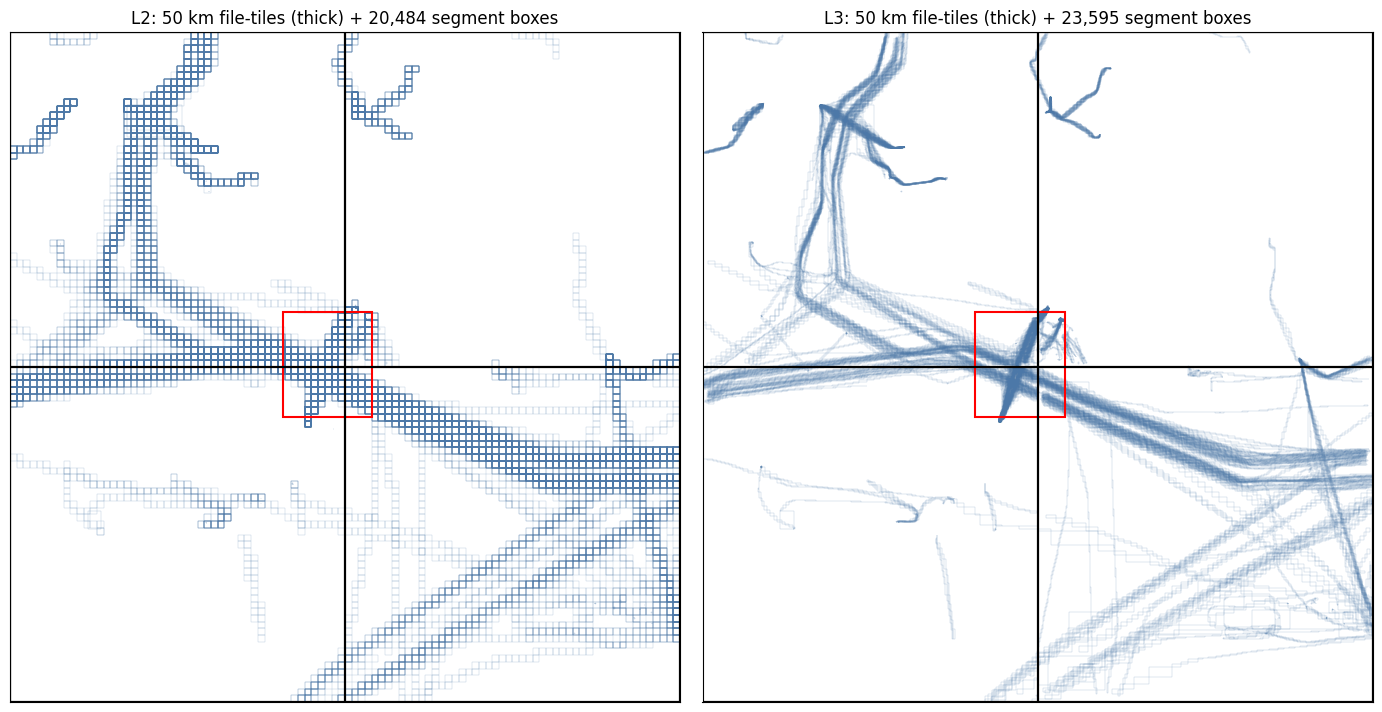

In [1]:
import duckdb as _ddb
import matplotlib.pyplot as _plt, matplotlib.patches as _mp
from bench.config import TRIPS_DEST   # local data/trips OR s3://warehouse/trips

_c = _ddb.connect()
if TRIPS_DEST.startswith("s3://"):     # read trips straight from MinIO
    _c.execute("INSTALL httpfs; LOAD httpfs;")
    _c.execute("CREATE SECRET (TYPE S3, KEY_ID 'admin', SECRET 'password', "
               "ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1');")
_COMPACT = f"{TRIPS_DEST.rstrip('/')}/layout_compact"

X0, X1, Y0, Y1 = 600_000, 700_000, 6_000_000, 6_100_000
TILE = 50_000
BELT = (640730, 6042487, 654100, 6058230)

fig, axes = _plt.subplots(1, 2, figsize=(14, 7))
for ax, name in zip(axes, ["L2", "L3"]):
    boxes = _c.execute(f"""
        SELECT xmin, ymin, xmax, ymax FROM read_parquet('{_COMPACT}/{name}/**/*.parquet')
        WHERE dt = DATE '2026-01-15'
          AND xmin >= {X0} AND xmax <= {X1} AND ymin >= {Y0} AND ymax <= {Y1}
    """).fetchall()
    for xmin, ymin, xmax, ymax in boxes:                       # thin blue = per-segment boxes
        ax.add_patch(_mp.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, ec="#4c78a8", lw=0.25, alpha=0.5))
    for gx in range(X0, X1 + 1, TILE):                          # thick black = 50 km file-tiles
        ax.axvline(gx, color="k", lw=1.6)
    for gy in range(Y0, Y1 + 1, TILE):
        ax.axhline(gy, color="k", lw=1.6)
    ax.add_patch(_mp.Rectangle((BELT[0], BELT[1]), BELT[2] - BELT[0], BELT[3] - BELT[1],
                               fill=False, ec="red", lw=1.5))   # red = alert belt
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}: 50 km file-tiles (thick) + {len(boxes):,} segment boxes")
_plt.tight_layout()
_plt.show()


Zoomed in, on a real map: The same boxes for one day, zoomed to the the belt on an OpenStreetMap basemap. Dashed lines = a 50 km file-tile boundary cutting
through the area (the belt straddles a tile corner); red = the alert belt. L2's uniform grid vs L3's lane-hugging adaptive boxes is obvious here.

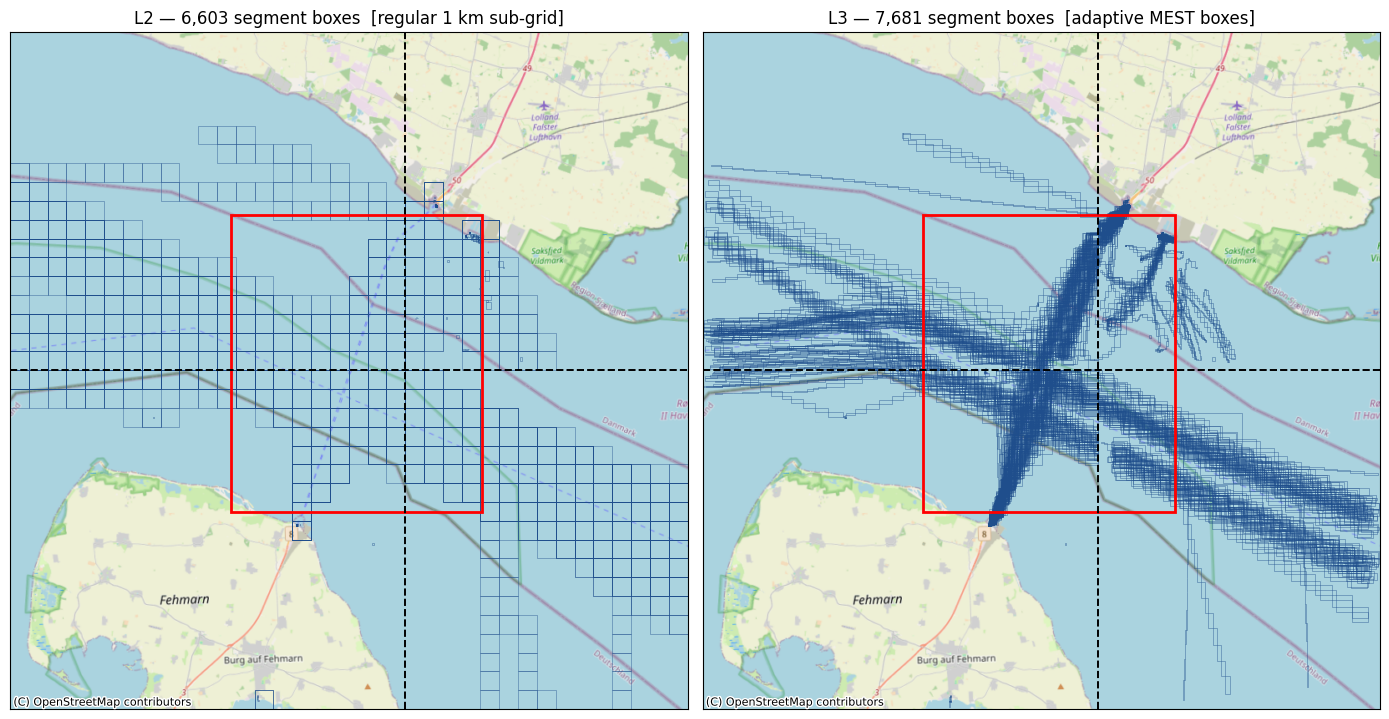

In [2]:
import duckdb as _ddb
import matplotlib.pyplot as _plt, matplotlib.patches as _mp
try:
    import contextily as _cx
except Exception:
    _cx = None
from bench.config import TRIPS_DEST   # local data/trips OR s3://warehouse/trips

_c = _ddb.connect()
if TRIPS_DEST.startswith("s3://"):     # read trips straight from MinIO
    _c.execute("INSTALL httpfs; LOAD httpfs;")
    _c.execute("CREATE SECRET (TYPE S3, KEY_ID 'admin', SECRET 'password', "
               "ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1');")
_COMPACT = f"{TRIPS_DEST.rstrip('/')}/layout_compact"

X0, X1, Y0, Y1 = 629_000, 665_000, 6_032_000, 6_068_000
BELT = (640730, 6042487, 654100, 6058230)

fig, axes = _plt.subplots(1, 2, figsize=(14, 7.5))
for ax, name in zip(axes, ["L2", "L3"]):
    boxes = _c.execute(f"""
        SELECT xmin, ymin, xmax, ymax FROM read_parquet('{_COMPACT}/{name}/**/*.parquet')
        WHERE dt = DATE '2026-01-15'
          AND xmin >= {X0} AND xmax <= {X1} AND ymin >= {Y0} AND ymax <= {Y1}
    """).fetchall()
    for xmin, ymin, xmax, ymax in boxes:                       # per-segment boxes
        ax.add_patch(_mp.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, ec="#1f4e8c", lw=0.4, alpha=0.7))
    ax.axvline(650_000, color="k", lw=1.4, ls="--")            # the 50 km file-tile boundary
    ax.axhline(6_050_000, color="k", lw=1.4, ls="--")
    ax.add_patch(_mp.Rectangle((BELT[0], BELT[1]), BELT[2] - BELT[0], BELT[3] - BELT[1],
                               fill=False, ec="red", lw=2))     # alert belt
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    tiling = "regular 1 km sub-grid" if name == "L2" else "adaptive MEST boxes"
    ax.set_title(f"{name} — {len(boxes):,} segment boxes  [{tiling}]")
    if _cx is not None:
        try:
            _cx.add_basemap(ax, crs="EPSG:32632", source=_cx.providers.OpenStreetMap.Mapnik)
        except Exception as e:
            print(f"{name}: basemap skipped ({type(e).__name__})")
_plt.tight_layout()
_plt.show()


## How it works

Three phases:
(1) build the data files (Parquet in object storage)
(2) register them in the Iceberg catalog
(3) query
All paths are relative to `packages/cli/`.

#### Step 1. Build: `../pipeline/run_pipeline.sh` (raw -> all layouts -> Parquet in MinIO)
One script runs these stages in order; each names the command/file that does it and what it writes.
The raw / L0 / daily / compact source layouts stay **local** (build inputs); the final `trips` layers
are written to MinIO (`TRIPS_DEST=s3://warehouse/trips`):

| stage | command / file | output |
|---|---|---|
| ingest | `lakehouse pipeline ingest-range` | `data/raw/aisdk-*.parquet` (raw AIS, local) |
| build L0 | `lakehouse pipeline build-l0` | `data/L0/…` (base trajectory segments, local) |
| daily layouts | `lakehouse pipeline build-layout L1..L4` | `data/layouts_daily/L{1..4}/` (local) |
| compact | `lakehouse pipeline compact-layout` | `data/layout_compact/L{1..4}/` (local) |
| trips schema | [scripts/build_trips.py](scripts/build_trips.py) | `$TRIPS_DEST/<layout>/` (the 11-col schema, §1) |
| Hilbert | [scripts/build_hilbert.py](scripts/build_hilbert.py) | `$TRIPS_DEST/.../LH` |
| sorted-compact | [scripts/build_sorted_compact.py](scripts/build_sorted_compact.py) | `$TRIPS_DEST/.../{L1s,L2s,L3s,L4s,LHs}` |

#### Step 2. Register in the Iceberg catalog [scripts/iceberg_to_s3.py](scripts/iceberg_to_s3.py)
pyiceberg writes each layout's table metadata
(manifests + the min/max stats used for pruning) into object storage and updates the catalog pointer.
So the data + metadata live on MinIO; the REST catalog is a thin pointer service. Services come from
[iceberg_rest/docker-compose.yml](iceberg_rest/docker-compose.yml) (env in
[iceberg_rest/env.rest](iceberg_rest/env.rest)):

```bash
source iceberg_rest/env.rest
python scripts/iceberg_to_s3.py all        # register every layout as ais.<layout>
```

#### Step 3. Query + measure [scripts/run_queries.py](scripts/run_queries.py) (and this notebook)
The engine asks the REST catalog for the table's current
metadata -> prunes via the min/max stats -> reads only the surviving Parquet from MinIO. It runs every layout × query × time-window from the `.sql` files and writes
[results/rest_all.csv](results/rest_all.csv) (5 book queries, [queries/iceberg/](queries/iceberg/)) +
[results/app_compare.csv](results/app_compare.csv) (8 app queries, [queries/app/](queries/app/)).
This notebook loads those two CSVs and draws the comparison charts.

## 1. Schema

### The `trips` schema (identical for every layout, only the file grouping differs)
Every layout exposes these same 11 columns, so the query text is identical across layouts. The
**bold** columns are what the engine uses to *prune* (skip data): a file/row-group is read only if
its stored min/max for these columns overlaps the query.
| column | type | role |
|---|---|---|
| `mmsi` | UBIGINT | vessel id |
| `ship_type` | VARCHAR | vessel type |
| `segment_type` | VARCHAR | `in motion` / `stationary` |
| `traj` | BLOB | the trajectory segment (MobilityDB `tgeompoint`, EWKB-encoded) |
| `tmin`, `tmax` | TIMESTAMP | **prunable time bounds** of the segment |
| `xmin, xmax, ymin, ymax` | DOUBLE | **prunable space bounds** (the segment's bounding box) |
| `dt` | DATE | **prunable date** |

In [29]:
import sys, re
sys.path.insert(0, ".")
import duckdb, pandas as pd, matplotlib.pyplot as plt
from bench.config import MOBILITYDUCK_EXT

def connect():
    """Open DuckDB and ATTACH the Iceberg REST catalog (MinIO warehouse)."""
    c = duckdb.connect(config={"allow_unsigned_extensions": "true"})
    c.execute("INSTALL iceberg; LOAD iceberg;")
    c.execute("INSTALL httpfs; LOAD httpfs;")
    c.execute(f"LOAD '{MOBILITYDUCK_EXT}';")
    c.execute("INSTALL spatial; LOAD spatial;")
    c.execute("CREATE SECRET (TYPE S3, KEY_ID 'admin', SECRET 'password', "
              "ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1');")
    c.execute("ATTACH '' AS lake (TYPE ICEBERG, ENDPOINT 'http://localhost:8181', "
              "AUTHORIZATION_TYPE 'none');")

    c.execute("SET VARIABLE t0   = TIMESTAMP '2026-01-15 08:00:00'")
    c.execute("SET VARIABLE t1   = TIMESTAMP '2026-01-16 08:00:00'")
    c.execute("SET VARIABLE tmid = TIMESTAMP '2026-01-15 20:00:00'")
    c.execute("SET VARIABLE d0   = DATE '2026-01-15'")
    c.execute("SET VARIABLE d1   = DATE '2026-01-16'")
    return c

con = connect()
con.execute("SELECT table_name FROM information_schema.tables "
            "WHERE table_catalog='lake' ORDER BY 1").df()

,table_name
0,L0
1,L1_daily
2,L1s
3,L2_daily
4,L2s
5,L3_daily
6,L3s
7,L4_daily
8,L4s
9,LH_daily


## 2. Example: Run a query

In [28]:
# Pick 1 layout
LAYOUT = "L2s"   # sorted-compact spaceSplit 
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM lake.ais.{LAYOUT}")

# q57.sql reads its time window from the session variables set in connect() (default = 1 day).
q57 = open("queries/iceberg/q57.sql").read()
print(q57)
con.execute(q57).df()   

WITH rodby AS (
    SELECT DISTINCT mmsi
    FROM trips
    WHERE xmin <= 651422.0 AND xmax >= 651135.0
      AND ymin <= 6058548.0 AND ymax >= 6058230.0
      AND tmin < getvariable('t1') AND tmax > getvariable('t0')
      AND eIntersects(tgeompointFromEWKB(traj),
                      ST_MakeEnvelope(651135.0, 6058230.0, 651422.0, 6058548.0))
),
puttgarden AS (
    SELECT DISTINCT mmsi
    FROM trips
    WHERE xmin <= 644896.0 AND xmax >= 644339.0
      AND ymin <= 6042487.0 AND ymax >= 6042108.0
      AND tmin < getvariable('t1') AND tmax > getvariable('t0')
      AND eIntersects(tgeompointFromEWKB(traj),
                      ST_MakeEnvelope(644339.0, 6042108.0, 644896.0, 6042487.0))
)
SELECT COUNT(*) AS n_both
FROM rodby r JOIN puttgarden pg USING (mmsi)
;



,n_both
0,4


## 3. Visualize result

Above query finds 4 vessels that visited both ferry ports. Plot their tracks 
on an OSM basemap. 

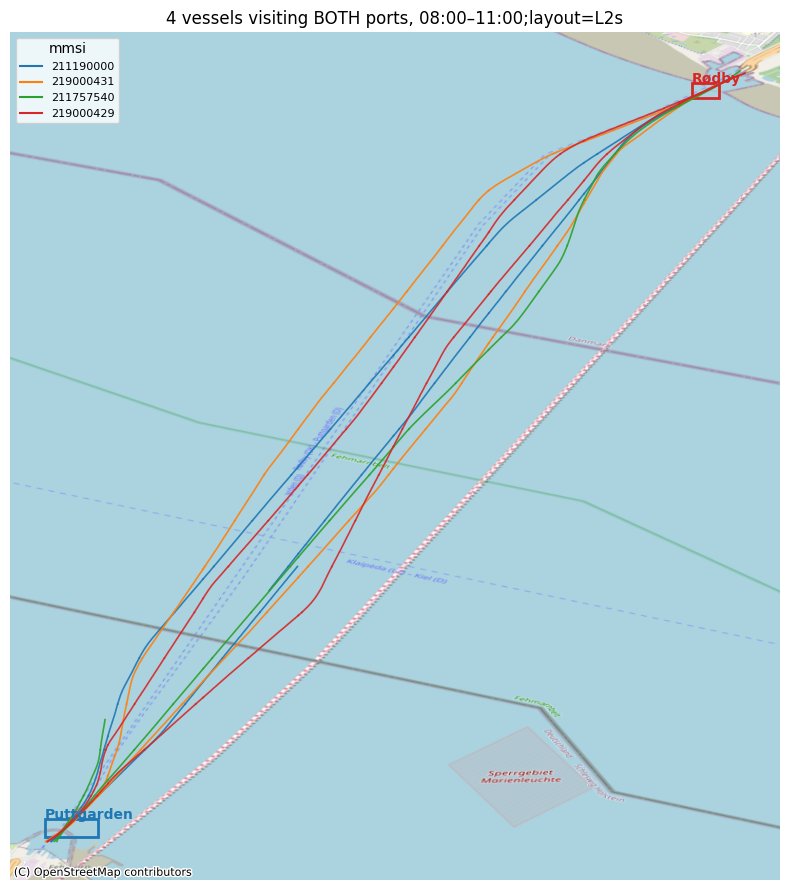

In [30]:
import contextily as cx, matplotlib.patches as mpatches

RODBY = (651135.0, 6058230.0, 651422.0, 6058548.0)
PUTT  = (644339.0, 6042108.0, 644896.0, 6042487.0)
BELT  = (640730.0, 6042487.0, 654100.0, 6058230.0)
W0, W1 = "2026-01-15 08:00:00", "2026-01-15 11:00:00"

both = con.execute(f"""
    WITH ports AS (SELECT ST_MakeEnvelope{RODBY} AS A, ST_MakeEnvelope{PUTT} AS B),
    cand AS (SELECT mmsi, traj FROM trips
             WHERE xmin<={BELT[2]} AND xmax>={BELT[0]} AND ymin<={BELT[3]} AND ymax>={BELT[1]}
               AND dt = DATE '2026-01-15'),
    a AS (SELECT DISTINCT mmsi FROM cand,ports p WHERE eIntersects(tgeompointFromEWKB(traj),p.A)),
    b AS (SELECT DISTINCT mmsi FROM cand,ports p WHERE eIntersects(tgeompointFromEWKB(traj),p.B))
    SELECT mmsi FROM a JOIN b USING(mmsi)
""").df()
mmsis = both.mmsi.tolist()
rows = con.execute(f"""
    SELECT mmsi, ST_AsText(trajectory(atTime(tgeompointFromEWKB(traj),
             span(TIMESTAMP '{W0}', TIMESTAMP '{W1}', true, false)))) AS wkt
    FROM trips
    WHERE mmsi IN ({','.join(map(str,mmsis))})
      AND xmin<={BELT[2]} AND xmax>={BELT[0]} AND ymin<={BELT[3]} AND ymax>={BELT[1]}
      AND tmin < TIMESTAMP '{W1}' AND tmax > TIMESTAMP '{W0}'
""").fetchall()

def segs(wkt):
    out = []
    for g in (re.findall(r"\(([^()]*)\)", wkt) if wkt else []):
        pts = [(float(p.split()[0]), float(p.split()[1])) for p in g.split(",") if len(p.split()) >= 2]
        if pts: out.append(pts)
    return out

fig, ax = plt.subplots(figsize=(8, 9))
colors = plt.cm.tab10.colors
for i, m in enumerate(mmsis):
    for mm, wkt in rows:
        if mm != m: continue
        for s in segs(wkt):
            xs, ys = zip(*s)                                  # already in EPSG:32632 metres
            ax.plot(xs, ys, color=colors[i % 10], lw=1.2, alpha=0.9)
    ax.plot([], [], color=colors[i % 10], label=str(m))
for box, name, c in [(RODBY, "Rødby", "tab:red"), (PUTT, "Puttgarden", "tab:blue")]:
    ax.add_patch(mpatches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                    fill=False, ec=c, lw=2))
    ax.annotate(name, (box[0], box[3]), color=c, fontsize=10, fontweight="bold")
try:
    cx.add_basemap(ax, crs="EPSG:32632", source=cx.providers.OpenStreetMap.Mapnik)
except Exception as e:
    print("basemap skipped (no network?):", e)
ax.set_title(f"{len(mmsis)} vessels visiting BOTH ports, 08:00–11:00;layout={LAYOUT}")
ax.set_axis_off(); ax.legend(title="mmsi", fontsize=8); plt.tight_layout(); plt.show()

## 4. Compare runtime across layouts

This is the core of the notebook: load the two result CSVs (written by
[scripts/run_queries.py](scripts/run_queries.py)) and draw the comparison charts.

- x-axis = selectivity = the query's time-window width(`hour`, `day`, `week`). A wider window asks for more data, so it's a "less selective" (harder) query. 
- The daily family and the sorted-compact family are drawn on separate figures as they're different storage strategies.

To (re)generate the CSVs:
```bash
source iceberg_rest/env.rest
python scripts/run_queries.py --iters 3 --sels hour,day,week, month   # -> results/rest_all.csv + app_compare.csv
```


### 4a. Book queries (Q5.7–Q5.11) 

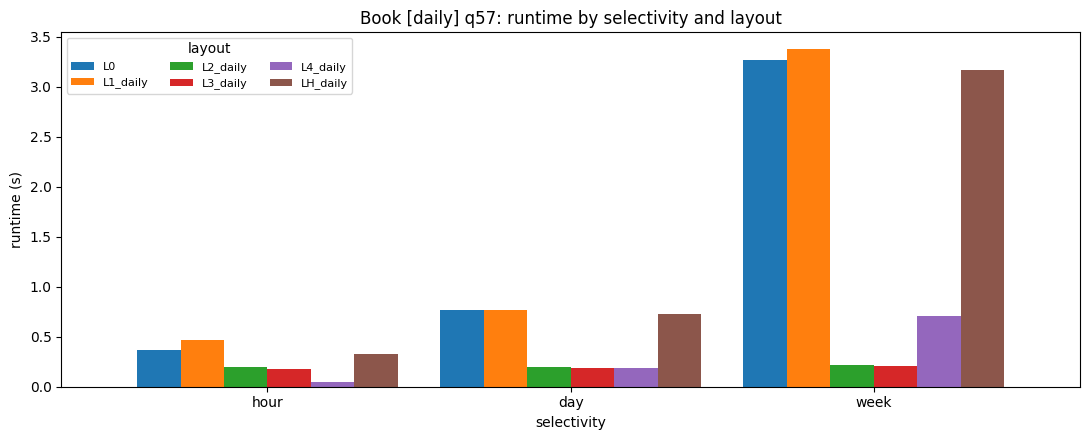

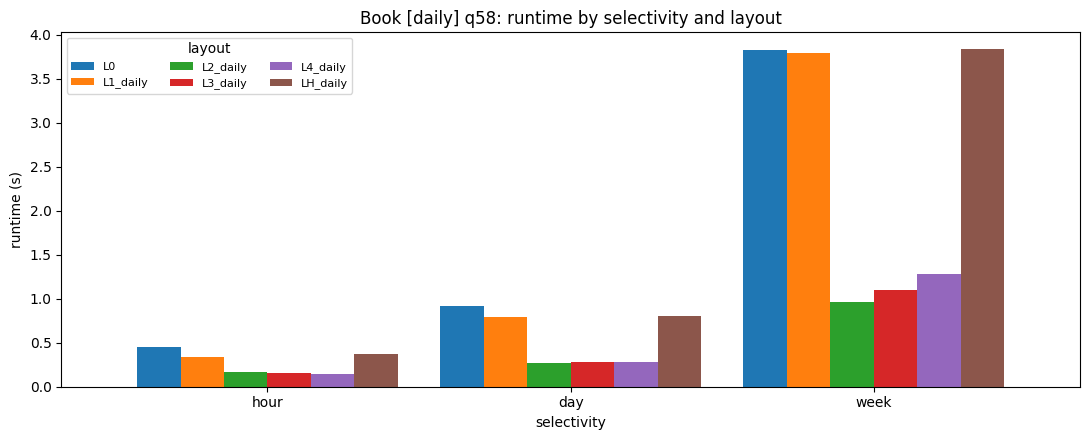

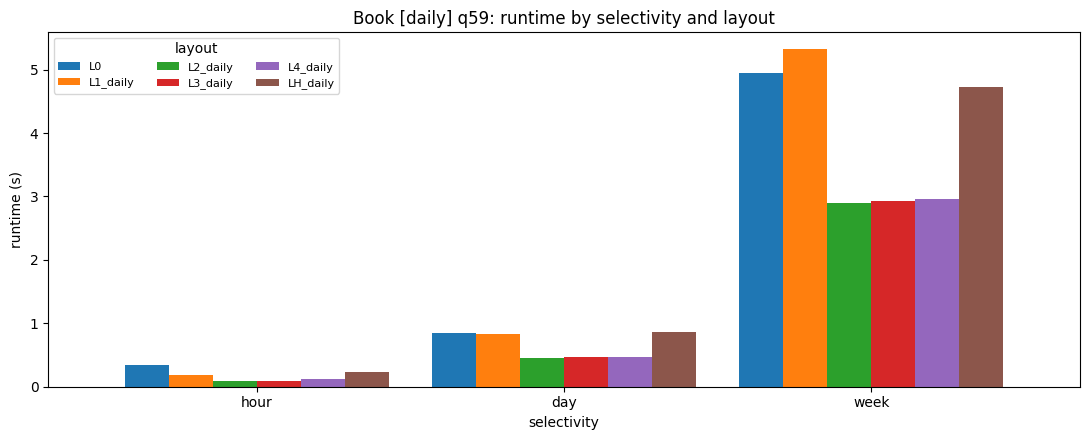

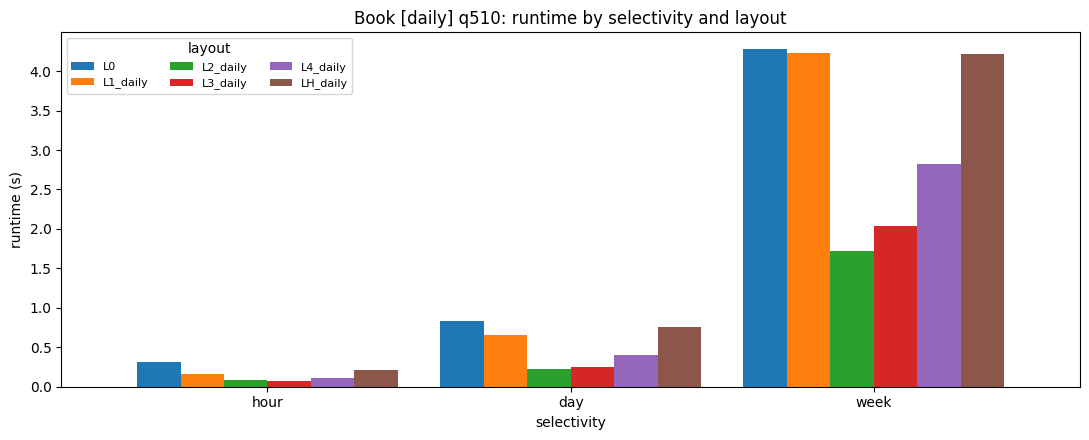

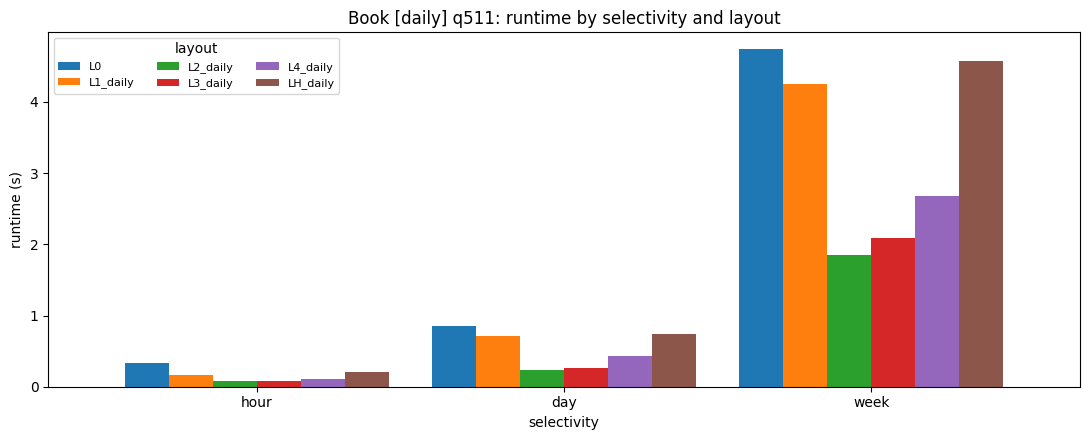

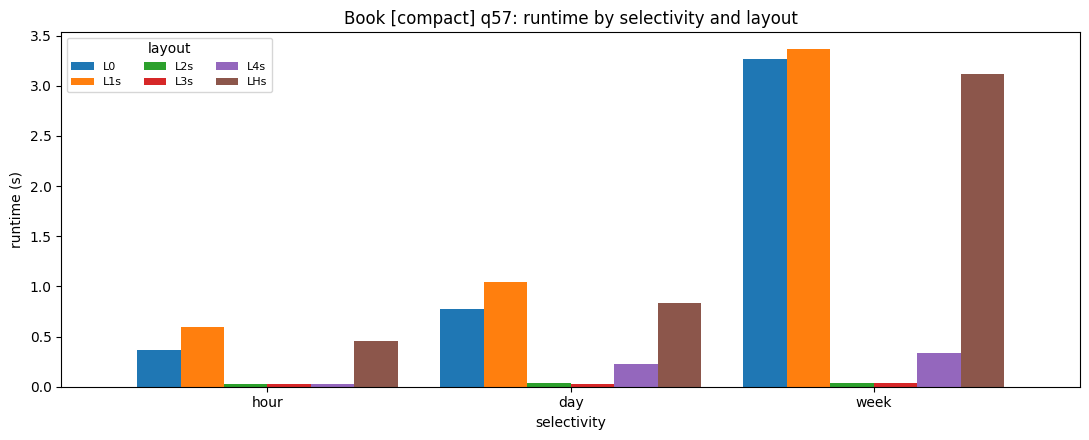

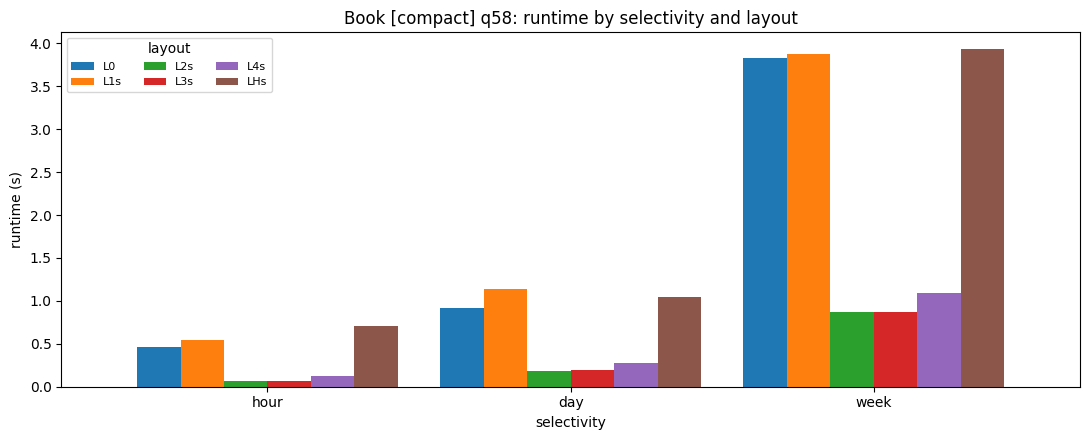

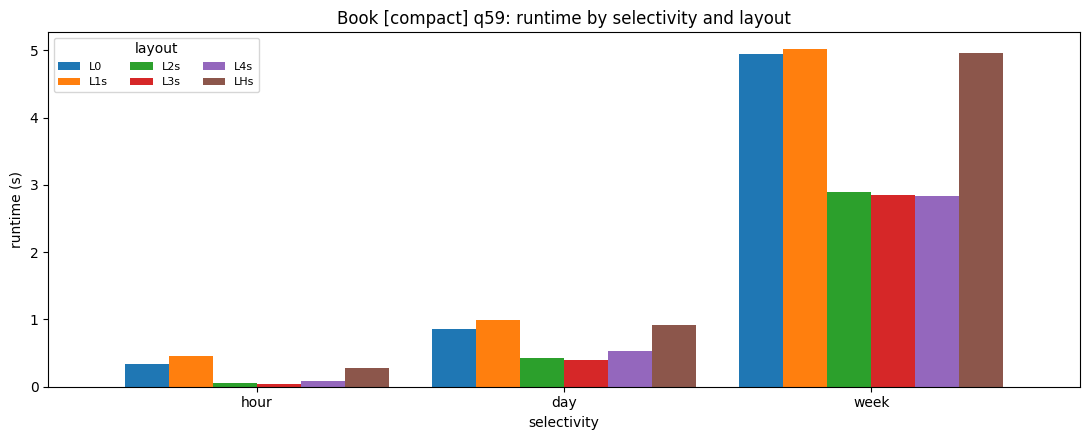

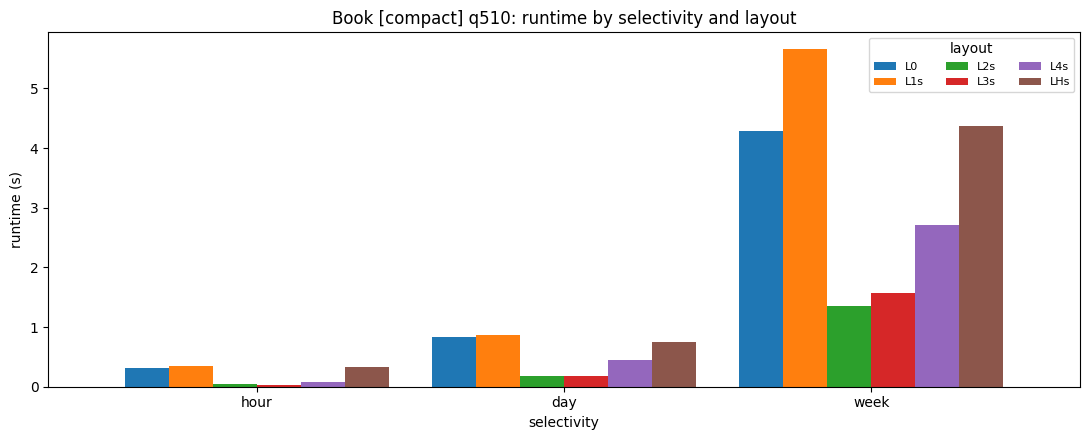

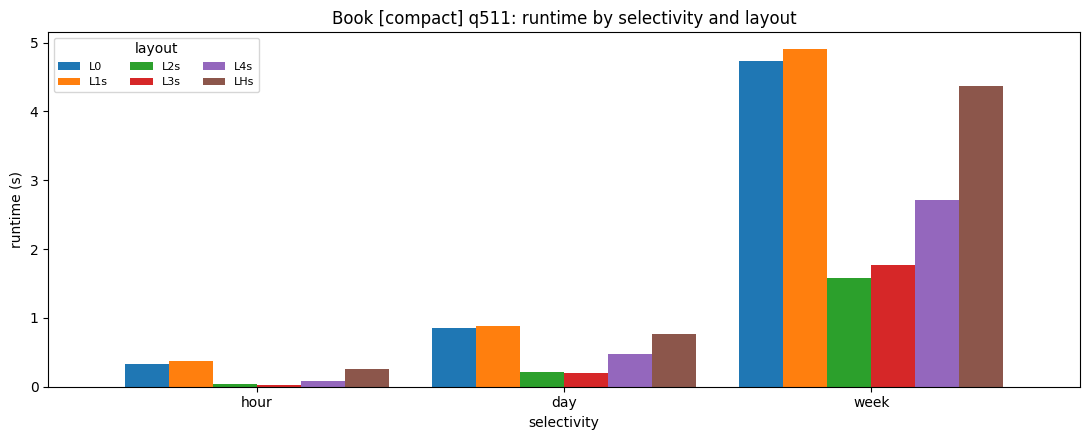

In [16]:
ORDER_DAILY   = ["L0", "L1_daily", "L2_daily", "L3_daily", "L4_daily", "LH_daily"]
ORDER_COMPACT = ["L0", "L1s", "L2s", "L3s", "L4s", "LHs"]
ORDER = ORDER_DAILY + [layout for layout in ORDER_COMPACT if layout not in ORDER_DAILY]
SELECTIVITY_ORDER = ["hour", "day", "week"]   # time-window selectivity (run_queries.py)

BARE = {"L0", "L1s", "L2s", "L3s", "L4s", "LHs"}
def layout_key(name, gran):
    return name if name in BARE else f"{name}_{gran}"

def plot_runtime_by_query(df, *, queries, query_col, layout_col, value_col, title_prefix, order):
    for query in queries:
        piv = df[df[query_col] == query].pivot_table(index="selectivity", columns=layout_col, values=value_col)
        piv = piv.reindex([s for s in SELECTIVITY_ORDER if s in piv.index])
        cols = [layout for layout in order if layout in piv.columns]
        if not cols:
            continue
        piv = piv[cols]
        ax = piv.plot.bar(figsize=(11, 4.5), width=0.86)
        ax.set_ylabel("runtime (s)")
        ax.set_xlabel("selectivity")
        ax.set_title(f"{title_prefix} {query}: runtime by selectivity and layout")
        ax.legend(title="layout", ncol=3, fontsize=8)
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.show()

book = pd.read_csv("results/rest_all.csv")
book["lk"] = [layout_key(n, g) for n, g in zip(book.layout, book.gran)]
BQ = ["q57", "q58", "q59", "q510", "q511"]

plot_runtime_by_query(book, queries=BQ, query_col="query", layout_col="lk",
                      value_col="runtime_trimmed_s", title_prefix="Book [daily]", order=ORDER_DAILY)
plot_runtime_by_query(book, queries=BQ, query_col="query", layout_col="lk",
                      value_col="runtime_trimmed_s", title_prefix="Book [compact]", order=ORDER_COMPACT)


### 4b. App queries (AIS-Explorer)


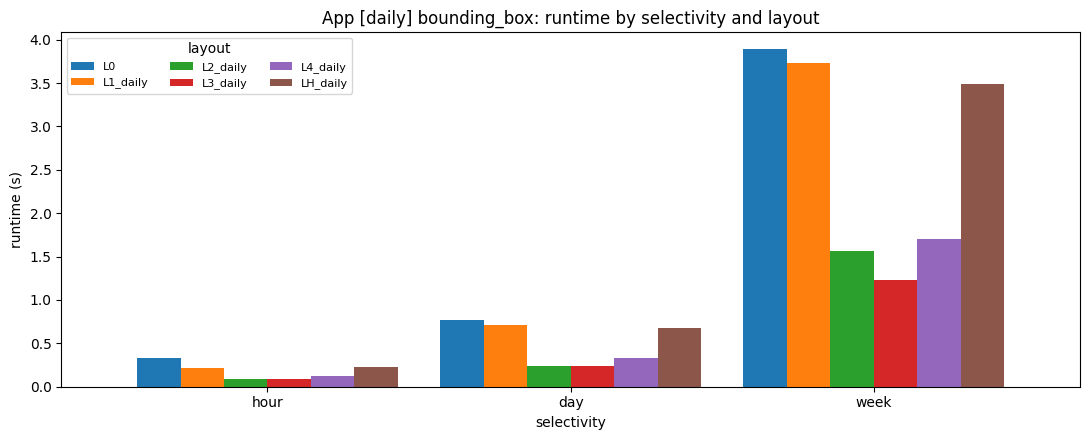

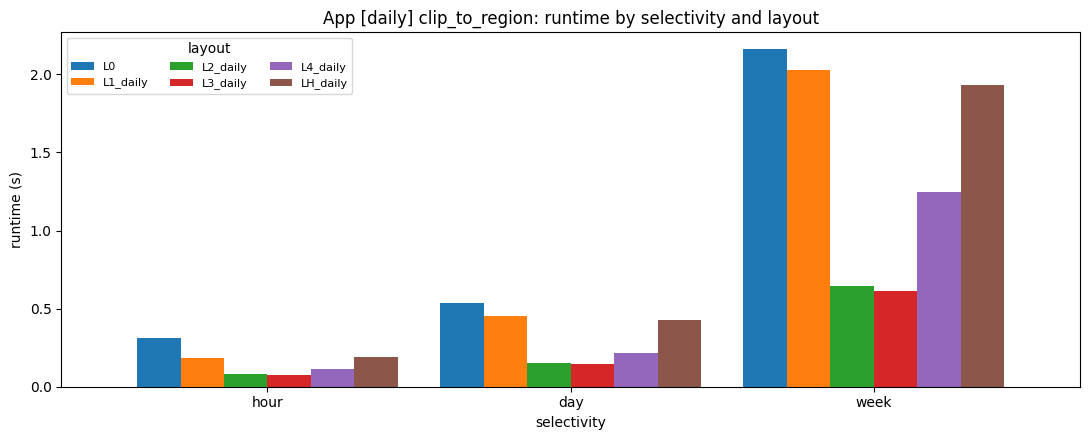

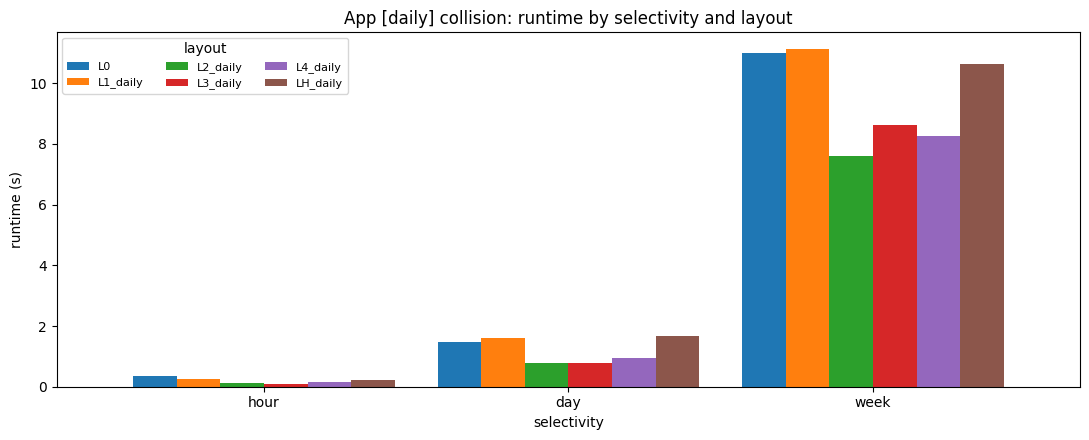

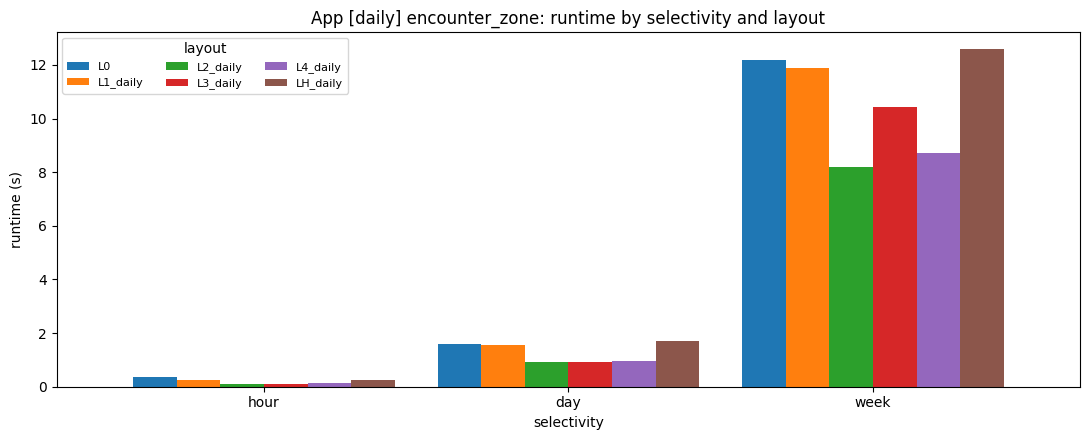

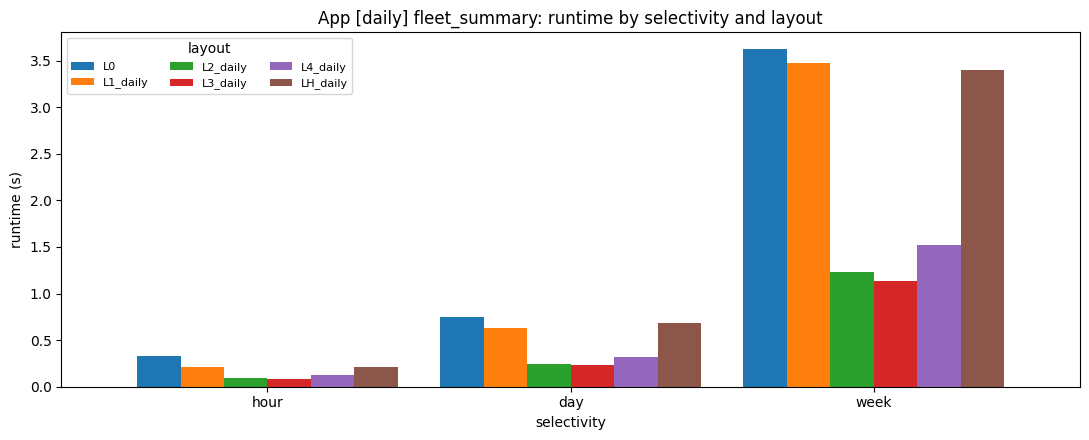

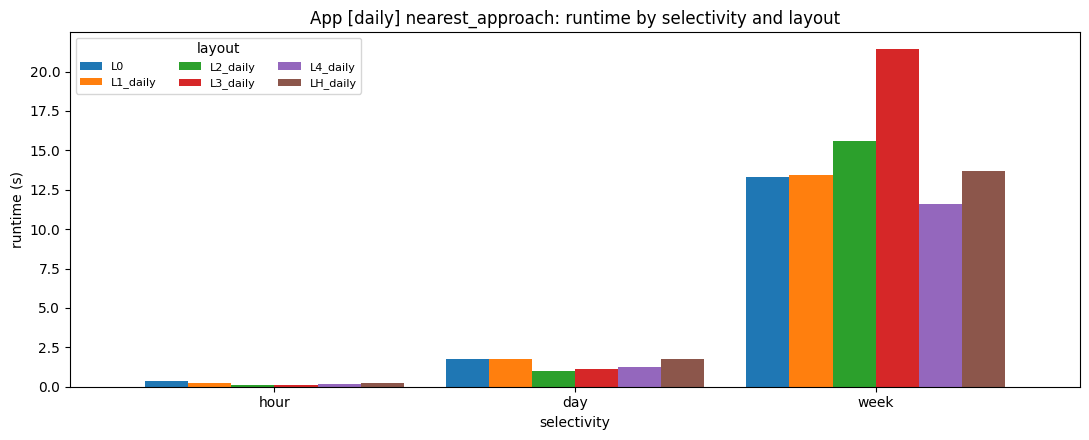

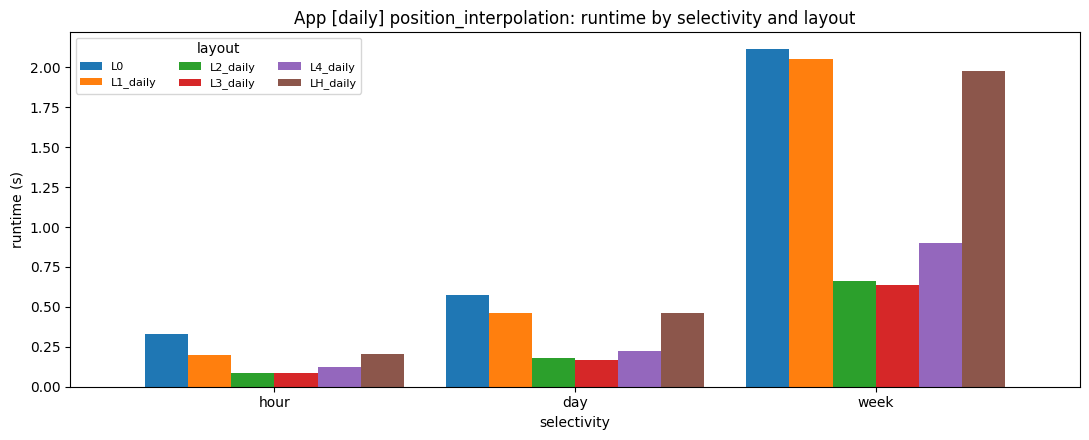

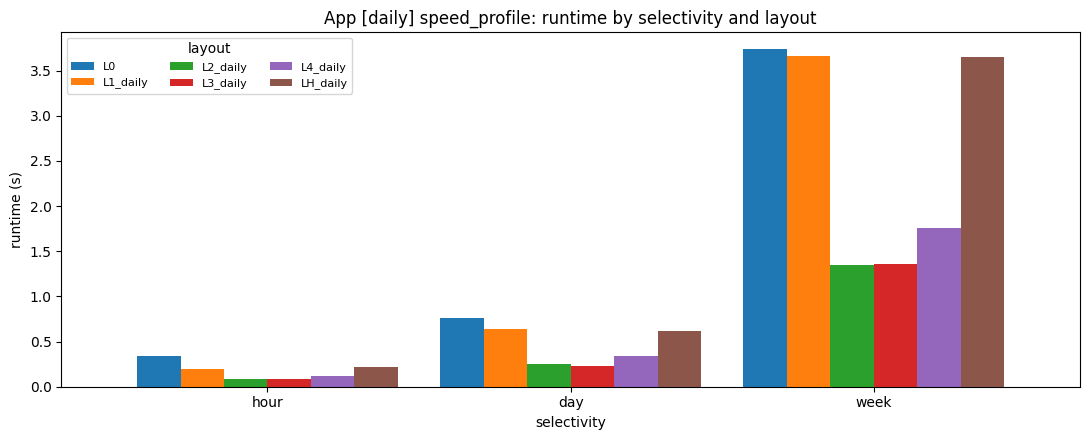

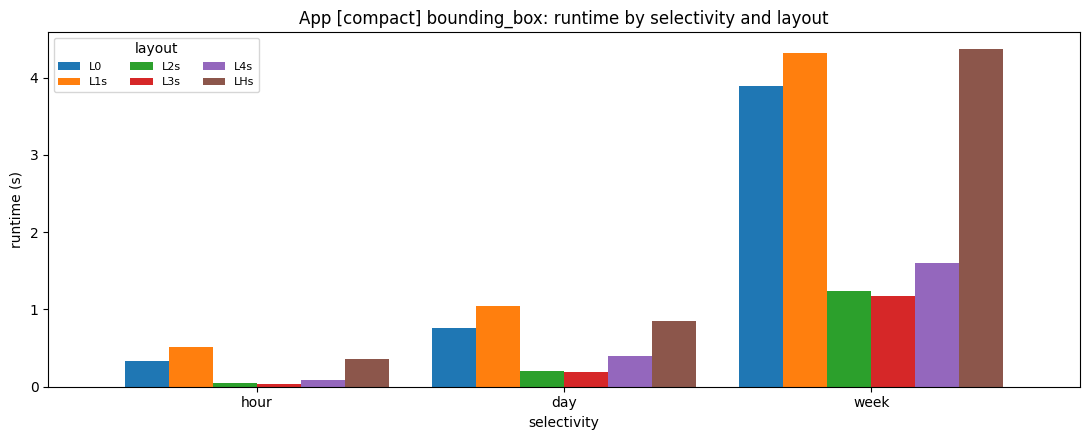

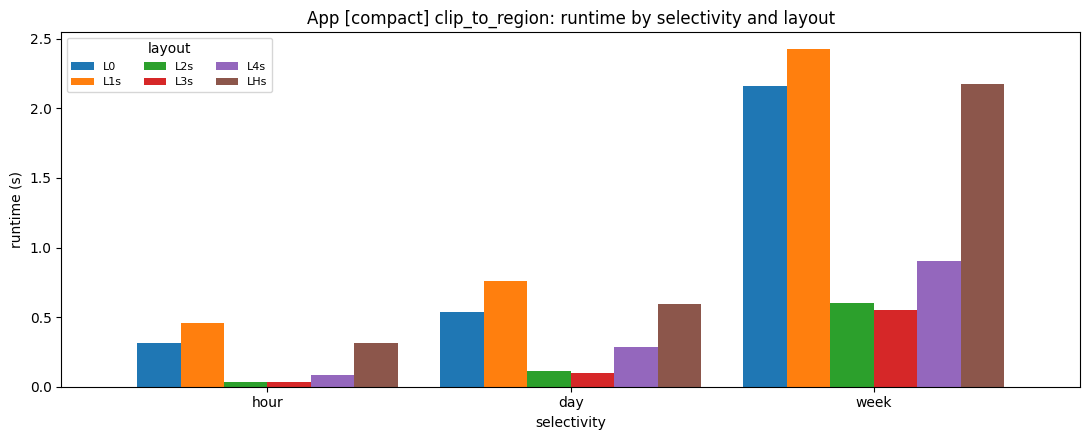

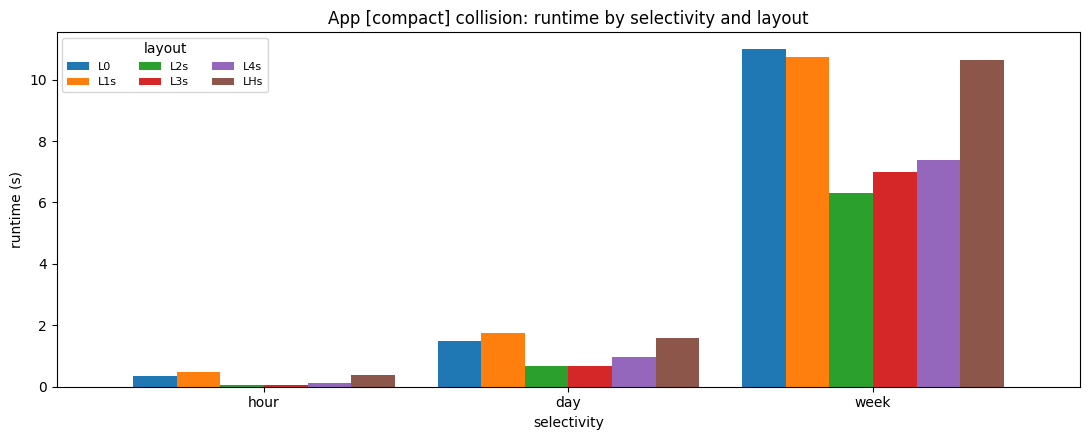

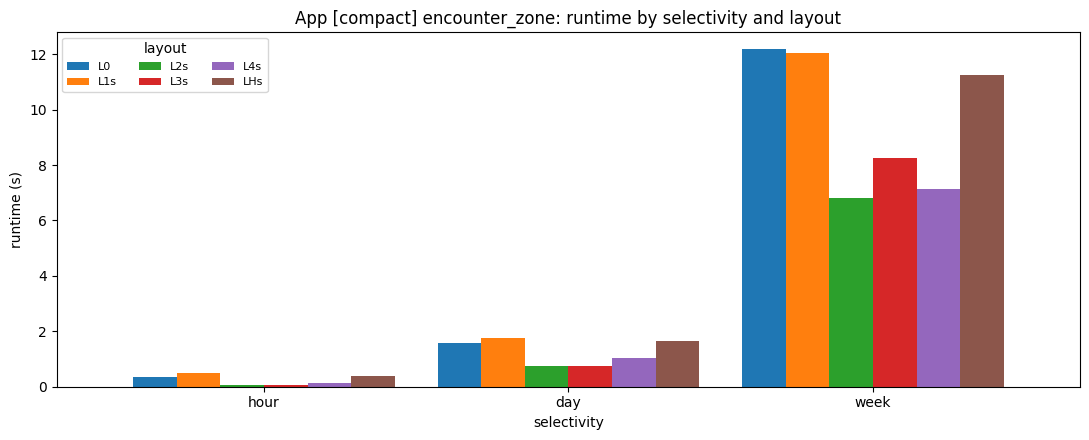

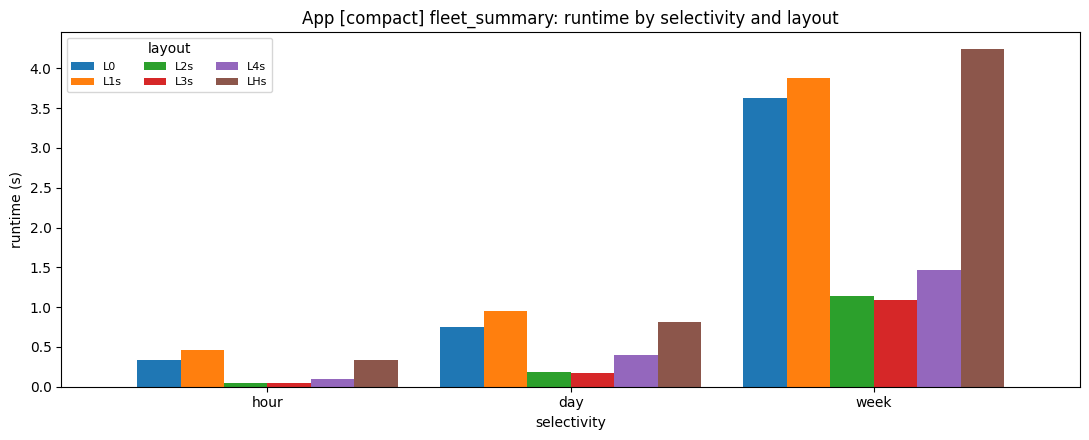

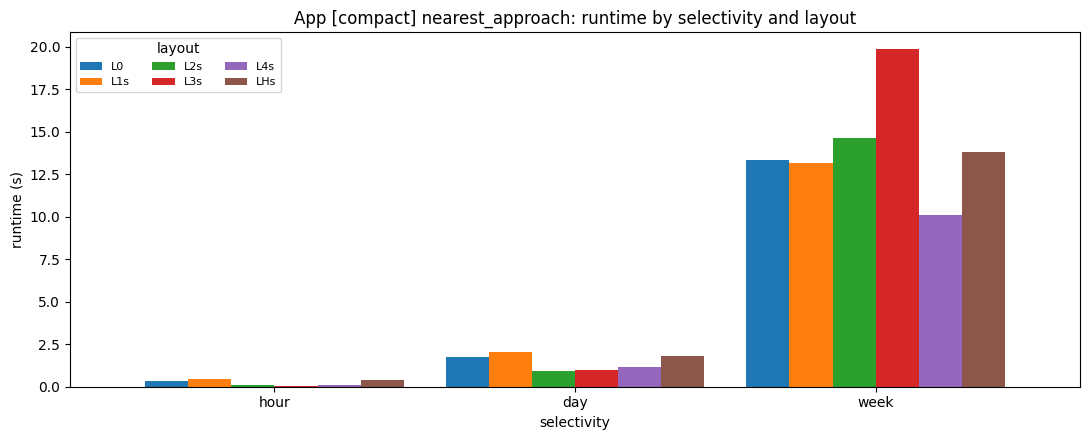

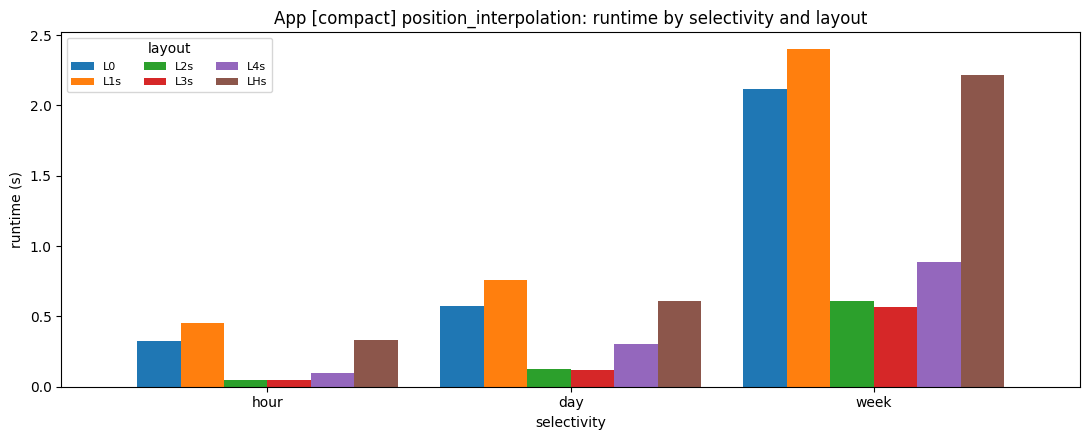

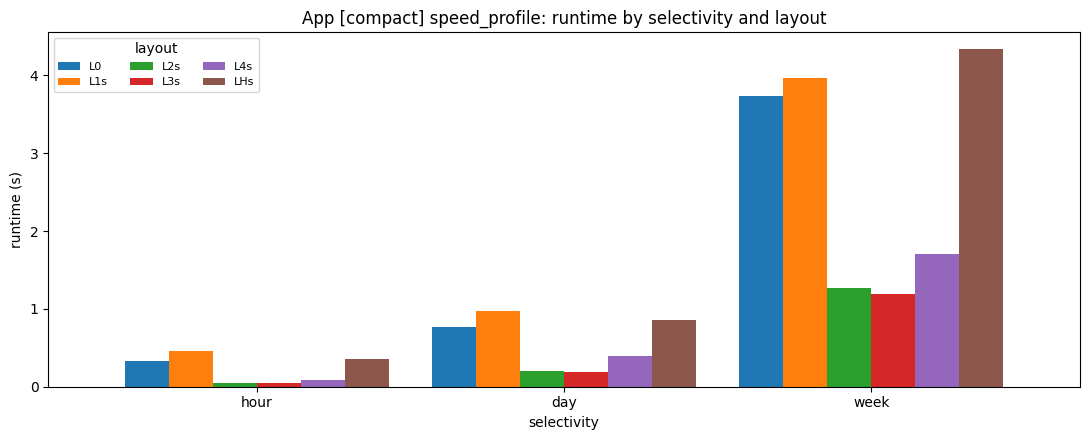

In [17]:
app = pd.read_csv("results/app_compare.csv")
AQ = sorted(app["query"].unique())

plot_runtime_by_query(app, queries=AQ, query_col="query", layout_col="layout",
                      value_col="runtime_s", title_prefix="App [daily]", order=ORDER_DAILY)
plot_runtime_by_query(app, queries=AQ, query_col="query", layout_col="layout",
                      value_col="runtime_s", title_prefix="App [compact]", order=ORDER_COMPACT)


### 4c. Overall speedup: compare with L0 baseline?

Per-query bars (4a/4b) are detailed but hard to summarise -> Collapse all queries (every query × time-window) speedup vs L0.

For each query, `speedup = (time on L0) / (time on this layout)`.
`2×` = twice as fast as the baseline; `1×` = same; `<1×` = slower than L0.

geometric mean (geomean): speedups are ratios. If a layout is
4× faster on one query and 4× slower (0.25×) on another, the honest summary is "about even"
(1×), which the geometric mean gives (√(4 × 0.25) = 1). A plain average would wrongly say
2.1×. So I report the geometric mean = the typical multiplicative speedup across all queries.
(In code it's the `geometric_mean` helper: multiply the ratios, take the n-th root.)

Charts below:
1. Daily layouts vs L0 (typical speedup).
2. Sorted-compact layouts vs L0 (typical speedup).
3. Sorted-compact vs its daily twin per query (does sorting+row-groups beat day-partitioning?).

The dashed line at **1×** = "no faster than L0". Bars to the right are wins.

In [ ]:
def combined_runtime_table(book, app):
    b = book[["query", "selectivity", "lk", "runtime_trimmed_s"]].rename(
        columns={"lk": "layout", "runtime_trimmed_s": "runtime_s"}
    ).copy()
    b["query"] = "book/" + b["query"].astype(str)

    a = app[["query", "selectivity", "layout", "runtime_s"]].copy()
    a["query"] = "app/" + a["query"].astype(str)

    both = pd.concat([b, a], ignore_index=True)
    both["case"] = both["query"] + " (" + both["selectivity"] + ")"   # one "case" per query×window
    return both

def geometric_mean(values):
    vals = pd.Series(values).dropna()
    vals = vals[vals > 0]
    if vals.empty:
        return pd.NA
    return float(vals.prod() ** (1 / len(vals)))

def speedup_vs_baseline(runtime, baseline, order=ORDER):
    piv = runtime.pivot_table(index="case", columns="layout", values="runtime_s")
    if baseline not in piv.columns:
        raise ValueError(f"missing baseline layout: {baseline}")
    speedups = piv.rdiv(piv[baseline], axis=0)   # baseline_time / layout_time, per case
    speedups = speedups.reindex(columns=[layout for layout in order if layout in speedups.columns])
    return speedups.apply(geometric_mean).dropna().sort_values()

def annotate_barh(ax, fmt="{:.2f}x"):
    x0, x1 = ax.get_xlim()
    pad = (x1 - x0) * 0.012
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(width + pad, patch.get_y() + patch.get_height() / 2, fmt.format(width),
                va="center", ha="left", fontsize=8)
    ax.set_xlim(x0, max(x1, max((p.get_width() for p in ax.patches), default=0) * 1.16))

def plot_speedup_barh(series, title, xlabel="typical speedup vs L0 (geometric mean)"):
    ax = series.plot.barh(figsize=(9, 5), color="#4c78a8")
    ax.axvline(1.0, color="k", lw=0.8, ls="--")          # 1x = no faster than baseline
    ax.set_xlabel(f"{xlabel}  —  ×")
    ax.set_ylabel("")
    ax.set_title(title)
    annotate_barh(ax)
    plt.tight_layout()
    plt.show()

runtime = combined_runtime_table(book, app)

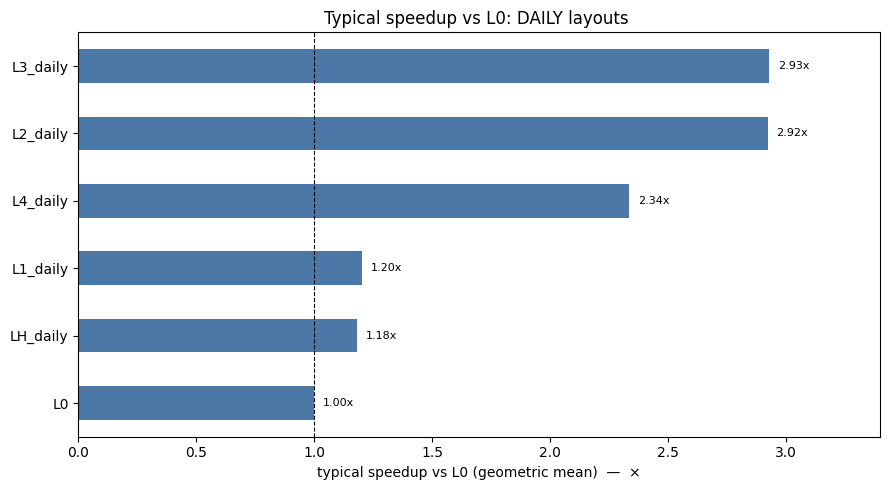

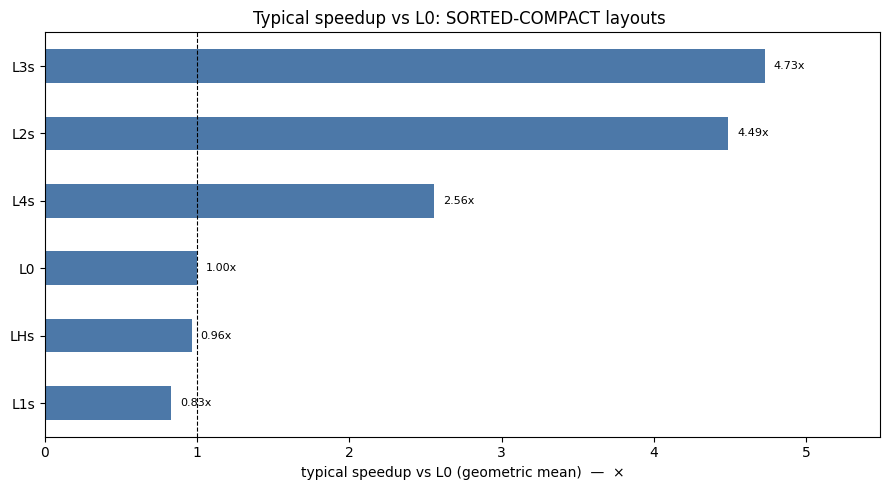

In [ ]:
# 1 & 2: typical speedup vs L0, daily and sorted-compact families on separate figures.
plot_speedup_barh(speedup_vs_baseline(runtime, "L0", ORDER_DAILY),
                  "Typical speedup vs L0: DAILY layouts ")
plot_speedup_barh(speedup_vs_baseline(runtime, "L0", ORDER_COMPACT),
                  "Typical speedup vs L0: SORTED-COMPACT layouts ")

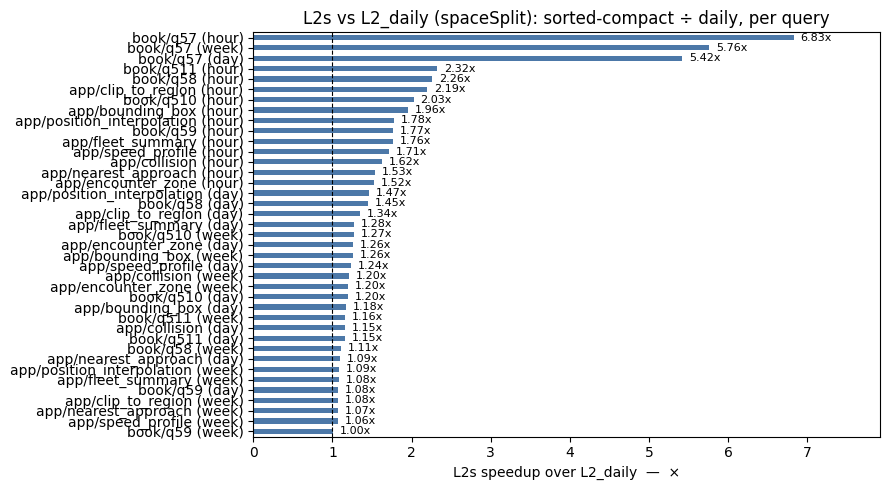

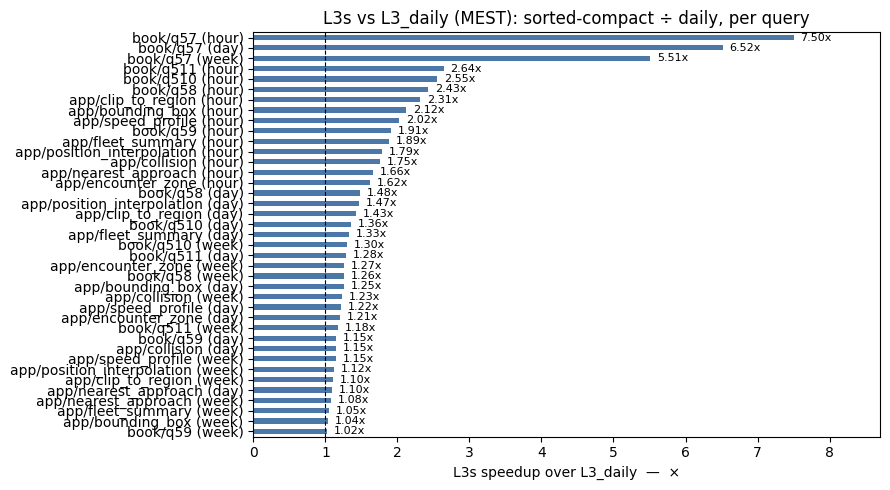

In [27]:
piv = runtime.pivot_table(index="case", columns="layout", values="runtime_s")
for tile, daily, sorted_ in [("spaceSplit", "L2_daily", "L2s"), ("MEST", "L3_daily", "L3s")]:
    if daily in piv.columns and sorted_ in piv.columns:
        ratio = (piv[daily] / piv[sorted_]).dropna().sort_values()
        plot_speedup_barh(ratio,
                          f"{sorted_} vs {daily} ({tile}): sorted-compact ÷ daily, per query",
                          xlabel=f"{sorted_} speedup over {daily}")


### 4d. Is the speedup worth the build cost?

A faster layout costs build time. Each layout is built on top of L0 (L0 = base segments), so its
real cost is `build(L0) + build(layout)`. This figure plots, for both families (daily, red; and
sorted-compact, blue), the extra build time (% of the L0 build, x-axis) against the typical
speedup vs L0 (geometric mean from 4c, y-axis). Top-left = cheap & fast (good); bottom-right =
expensive & slow.

Build times are summed `total_s` from the logs / `build_*.py`. Each sorted-compact layout costs
its daily twin's build + a cheap (~18 s) sort rewrite, so it sits directly above its twin:
≈ the same build cost, but more speed. The hash/Hilbert
ones (L1s, LHs) stay below 1×, cheap to build but no advanced pruning.

,family,extra_build_pct,speedup
layout,,,
L1,daily,3.9,1.2
L2,daily,218.0,2.9
L3,daily,87.7,2.9
L4,daily,150.8,2.3
LH,daily,5.7,1.2
L1s,sorted-compact,5.1,0.8
L2s,sorted-compact,219.4,4.5
L3s,sorted-compact,89.1,4.7
L4s,sorted-compact,152.3,2.6


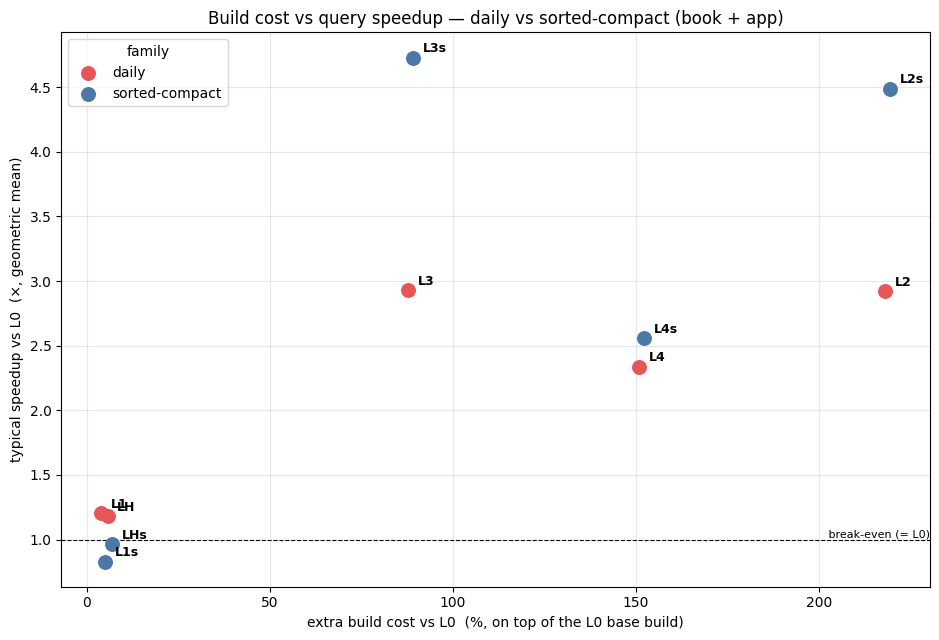

In [24]:
BUILD_S = {"L0":1343.7, "L1_daily": 52.0, "L2_daily": 2901.1 + 28.2,"L3_daily": 1140.0 * 31 / 30,       
    "L4_daily": 2025.9, "LH_daily": 77.2}
SORT_S = {"L1s": 16.2, "L2s": 18.7, "L3s": 18.9, "L4s": 20.2, "LHs": 17.7}  
TWIN = {"L1s": "L1_daily", "L2s": "L2_daily", "L3s": "L3_daily", "L4s": "L4_daily", "LHs": "LH_daily"}
L0_BUILD = BUILD_S["L0"]

# Typical speedup vs L0 
sp_daily = speedup_vs_baseline(runtime, "L0", ORDER_DAILY)
sp_comp = speedup_vs_baseline(runtime, "L0", ORDER_COMPACT)

rows = []
for layout in ["L1_daily", "L2_daily", "L3_daily", "L4_daily", "LH_daily"]:
    rows.append({"layout": layout.replace("_daily", ""), "family": "daily",
                 "extra_build_pct": 100.0 * BUILD_S[layout] / L0_BUILD,
                 "speedup": float(sp_daily.get(layout, float("nan")))})
for layout in ["L1s", "L2s", "L3s", "L4s", "LHs"]:
    extra = BUILD_S[TWIN[layout]] + SORT_S[layout]        # daily-twin build + the sort rewrite
    rows.append({"layout": layout, "family": "sorted-compact",
                 "extra_build_pct": 100.0 * extra / L0_BUILD,
                 "speedup": float(sp_comp.get(layout, float("nan")))})
cost = pd.DataFrame(rows).set_index("layout")
display(cost.round(1))

fig, ax = plt.subplots(figsize=(9.5, 6.5))
for fam, color in [("daily", "#e45756"), ("sorted-compact", "#4c78a8")]:
    sub = cost[cost.family == fam]
    ax.scatter(sub["extra_build_pct"], sub["speedup"], s=95, color=color, label=fam, zorder=3)
    for layout, r in sub.iterrows():
        ax.annotate(layout, (r["extra_build_pct"], r["speedup"]),
                    textcoords="offset points", xytext=(7, 4), fontsize=9, fontweight="bold")
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.text(ax.get_xlim()[1], 1.0, " break-even (= L0)", va="bottom", ha="right", fontsize=8, color="k")
ax.set_xlabel("extra build cost vs L0  (%, on top of the L0 base build)")
ax.set_ylabel("typical speedup vs L0  (×, geometric mean)")
ax.set_title("Build cost vs query speedup — daily vs sorted-compact (book + app)")
ax.legend(title="family")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4e. The winners (L2s / L3s) vs the Hilbert layout (LH_daily), per query

How much faster are the recommended sorted-compact spatial layouts (L2s, L3s) than LH_daily (Hilbert order, day-partitioned)? One bar pair per query = typical speedup over LH_daily (geometric mean across the hour/day/week windows). `>1×` means the
spatial layout is faster than Hilbert.

,L2s,L3s
case,,
app/bounding_box,3.60,3.93
app/clip_to_region,4.02,4.44
app/collision,2.45,2.48
app/encounter_zone,2.46,2.38
app/fleet_summary,3.55,3.86
app/nearest_approach,1.85,1.71
app/position_interpolation,3.68,3.93
app/speed_profile,3.30,3.65
book/q510,4.09,4.32


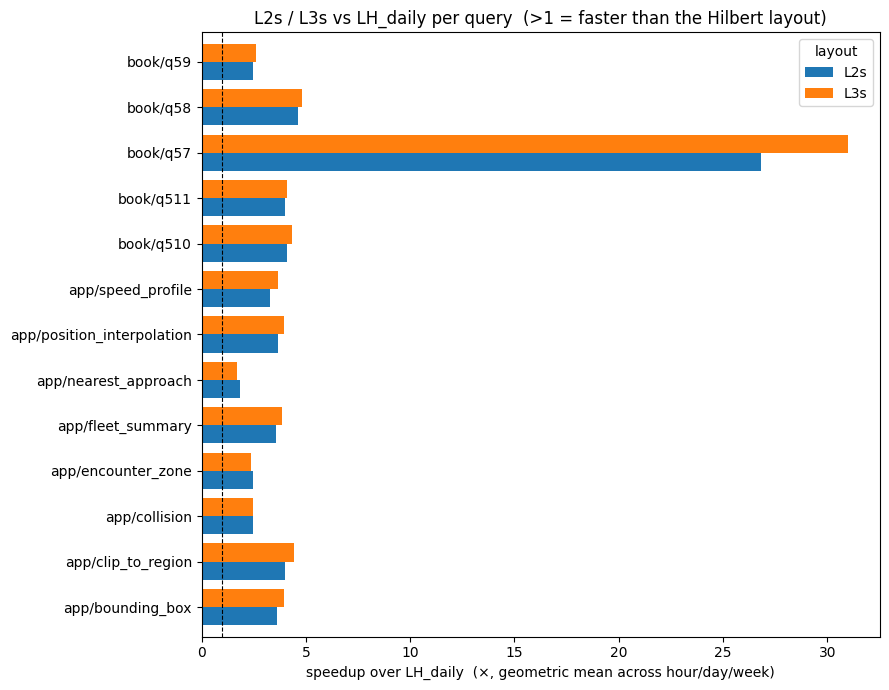

In [26]:
# Per-query speedup of L2s / L3s over LH_daily 
piv_e = runtime.pivot_table(index="case", columns="layout", values="runtime_s")
query_of = piv_e.index.to_series().str.replace(r"\s*\(.*\)$", "", regex=True)   # drop "(window)"

vs_lh = pd.DataFrame({
    layout: (piv_e["LH_daily"] / piv_e[layout]).groupby(query_of).apply(geometric_mean)
    for layout in ["L2s", "L3s"] if layout in piv_e.columns
}).sort_index()
display(vs_lh.round(2))

ax = vs_lh.plot.barh(figsize=(9, 7), width=0.8)
ax.axvline(1.0, color="k", lw=0.8, ls="--")          # 1x = same speed as LH_daily
ax.set_xlabel("speedup over LH_daily  (×, geometric mean across hour/day/week)")
ax.set_ylabel("")
ax.set_title("L2s / L3s vs LH_daily per query  (>1 = faster than the Hilbert layout)")
ax.legend(title="layout")
plt.tight_layout()
plt.show()


### 4f. Storage 

Every layout holds the same trajectories, so the total bytes are similar (~3.3–3.9 GB; the
`traj` blob dominates and compresses the same regardless of grouping). Two things differ a lot, and
both are real costs to weigh against the speed wins above:

- Row count: spatial tiling (L2 / L3) splits each trajectory segment at every tile border,
  so it stores ~17–22× more rows than the layouts that keep whole segments (L0, L1 hash, LH
  Hilbert). More rows = a bit more bytes and a lot more internal metadata.
- File count: from 16 files (L1s, huge files) to 4154(L2_daily, tiny files). Thousands
  of tiny files add open/metadata overhead; the sorted-compact `…s` layouts pack the same data into
  ~13× fewer files than their daily twins (e.g. L2s = 302 files vs L2_daily = 4154), which is a
  big part of why they're both fast and easier to manage.

,files,size_MB,rows,MB_per_file
layout,,,,
L0,31,3554.2,381713,114.65
L1_daily,496,3552.1,381713,7.16
L2_daily,4154,3826.5,6749935,0.92
L3_daily,4133,3889.6,8232719,0.94
L4_daily,744,3363.7,672860,4.52
LH_daily,279,3541.1,381713,12.69
L1s,16,3342.2,381713,208.89
L2s,302,3722.5,6749935,12.33
L3s,299,3793.6,8232719,12.69


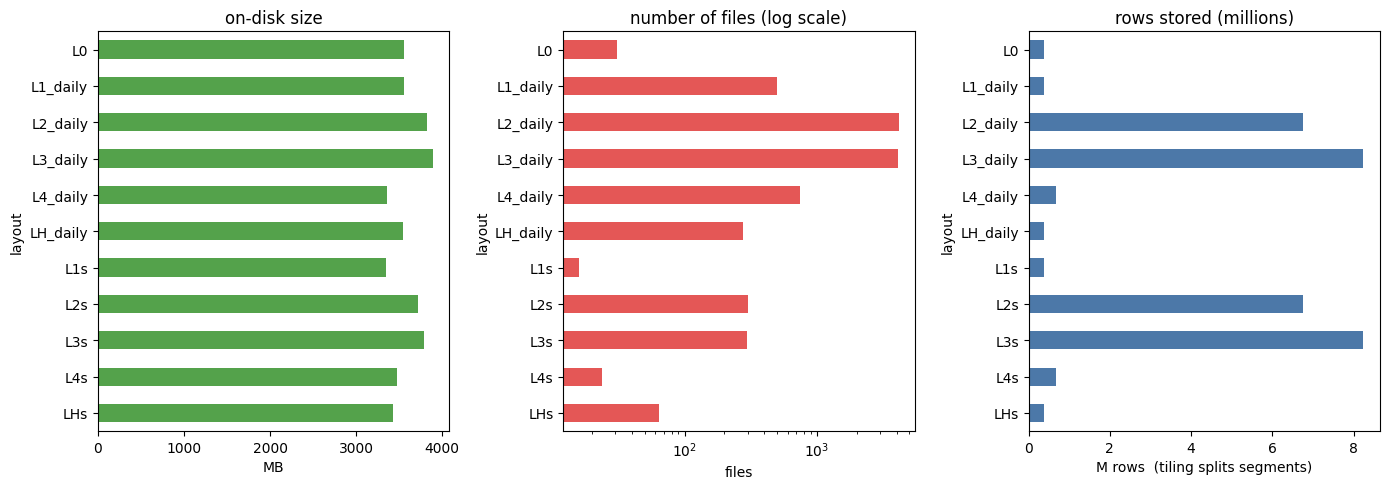

In [25]:
from bench.config import layouts as _layouts, trips_glob

srows = []
for ls in _layouts():
    g = trips_glob(ls)
    try:
        nf, rows = con.execute(
            f"SELECT count(DISTINCT file_name), sum(num_rows) "
            f"FROM parquet_file_metadata('{g}')").fetchone()
        size_mb = con.execute(
            f"SELECT sum(total_compressed_size)/1e6 FROM parquet_metadata('{g}')").fetchone()[0]
    except Exception:
        continue   # layout not built (e.g. experimental L2H) — no files match the glob
    if not nf:
        continue
    srows.append({"layout": ls.key, "files": int(nf), "size_MB": round(size_mb, 1),
                  "rows": int(rows), "MB_per_file": round(size_mb / nf, 2)})

storage = pd.DataFrame(srows).set_index("layout")
storage = storage.reindex([l for l in ORDER if l in storage.index] +
                          [l for l in storage.index if l not in ORDER])   # daily then sorted-compact
display(storage)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
storage["size_MB"].plot.barh(ax=axes[0], color="#54a24b")
axes[0].set_title("on-disk size"); axes[0].set_xlabel("MB"); axes[0].invert_yaxis()
storage["files"].plot.barh(ax=axes[1], color="#e45756")
axes[1].set_title("number of files (log scale)"); axes[1].set_xlabel("files"); axes[1].set_xscale("log"); axes[1].invert_yaxis()
(storage["rows"] / 1e6).plot.barh(ax=axes[2], color="#4c78a8")
axes[2].set_title("rows stored (millions)"); axes[2].set_xlabel("M rows  (tiling splits segments)"); axes[2].invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Data lake vs Lakehouse
This section compares the classic data lake vs lakehouse, to isolate what the Iceberg catalog itself gives us.

Both sides run the ame queries, the same selectivity windows, over the identical Parquet
files on MinIO. The runs are produced by 2 scripts and saved as 2 CSVs with the same schema; here just compare them:

| side | script | result CSV | how to read data |
|---|---|---|---|
| **data lake** | [scripts/run_parquet.py](scripts/run_parquet.py) | `results/parquet_all.csv` | `read_parquet(...)`, no catalog |
| **lakehouse** | [scripts/run_queries.py](scripts/run_queries.py) | `results/rest_all.csv` | `FROM lake.ais.<layout>`, manifest skips files before opening them |

Regenerate the data-lake side (the lakehouse side already exists) with:
```bash
source iceberg_rest/env.rest
python scripts/run_parquet.py --kinds book --sels hour,day,week
``


165 paired rows (layout × query × window);  answer mismatches: 0


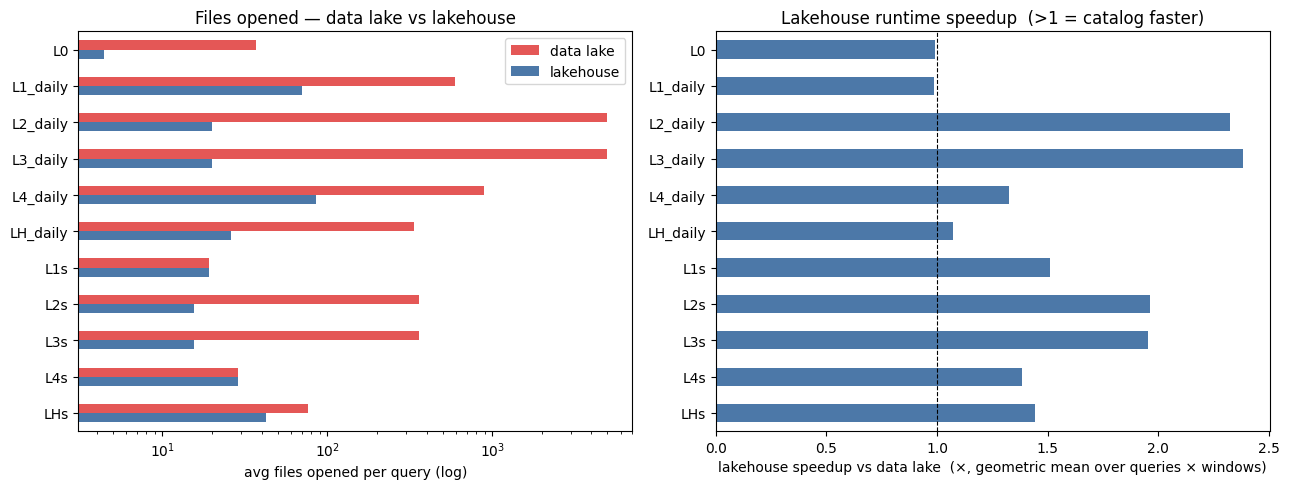

In [29]:
import numpy as np

KEYCOLS = ["layout", "gran", "query", "selectivity"]
dl = pd.read_csv("results/parquet_all.csv")   # data lake  (run_parquet.py)
lh = pd.read_csv("results/rest_all.csv")       # lakehouse   (run_queries.py)
cmp = dl.merge(lh, on=KEYCOLS, suffixes=("_dl", "_lh"))

bad = cmp[cmp.answer_dl.astype(str) != cmp.answer_lh.astype(str)]
print(f"{len(cmp)} paired rows (layout × query × window);  answer mismatches: {len(bad)}")
if len(bad):
    display(bad[KEYCOLS + ["answer_dl", "answer_lh"]])

BARE = {"L0", "L1s", "L2s", "L3s", "L4s", "LHs"}
cmp["lk"] = [n if n in BARE else f"{n}_{g}" for n, g in zip(cmp.layout, cmp.gran)]
cmp["files_skipped_pct"] = 100 * (1 - cmp.files_read_lh / cmp.files_read_dl)
cmp["lh_speedup_x"] = cmp.runtime_trimmed_s_dl / cmp.runtime_trimmed_s_lh

def geomean(s):                          # geometric mean: the right average for ratios
    s = pd.Series(s).dropna(); s = s[s > 0]
    return float(np.exp(np.log(s).mean())) if len(s) else np.nan

ORDER = ["L0", "L1_daily", "L2_daily", "L3_daily", "L4_daily", "LH_daily",
         "L1s", "L2s", "L3s", "L4s", "LHs"]
order = [l for l in ORDER if l in set(cmp.lk)]

summary = (cmp.groupby("lk")
              .agg(files_dl=("files_read_dl", "mean"),
                   files_lh=("files_read_lh", "mean"),
                   lh_speedup_x=("lh_speedup_x", geomean))
              .reindex(order))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
summary[["files_dl", "files_lh"]].plot.barh(ax=axes[0], color=["#e45756", "#4c78a8"])
axes[0].set_xscale("log"); axes[0].invert_yaxis()
axes[0].set_xlabel("avg files opened per query (log)"); axes[0].set_ylabel("")
axes[0].set_title("Files opened — data lake vs lakehouse"); axes[0].legend(["data lake", "lakehouse"])
summary["lh_speedup_x"].plot.barh(ax=axes[1], color="#4c78a8")
axes[1].axvline(1.0, color="k", lw=0.8, ls="--"); axes[1].invert_yaxis()
axes[1].set_xlabel("lakehouse speedup vs data lake  (×, geometric mean over queries × windows)")
axes[1].set_ylabel(""); axes[1].set_title("Lakehouse runtime speedup  (>1 = catalog faster)")
plt.tight_layout(); plt.show()